In [27]:
import pandas as pd 
col_names= [
    "age",
    "gender",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels",
    "thalassemia"
]
df=pd.read_csv("heart.csv",header=1,names=col_names)

In [28]:
print("Shape:", df.shape)          # rows, columns
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe())


Shape: (1024, 13)

Data Types:
 age                          int64
gender                       int64
chest_pain_type              int64
resting_blood_pressure       int64
cholesterol                  int64
fasting_blood_sugar          int64
resting_ecg                  int64
max_heart_rate               int64
exercise_induced_angina    float64
st_depression                int64
st_slope                     int64
num_major_vessels            int64
thalassemia                  int64
dtype: object

Null Values:
 age                        0
gender                     0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
st_slope                   0
num_major_vessels          0
thalassemia                0
dtype: int64

Summary Statistics:
                age       gender  chest_pain_type  resting_blood_pressure

In [30]:
df.head()

,age,gender,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia
53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
58,0,0,100,248,0,0,122,0,1.0,1,0,2,1


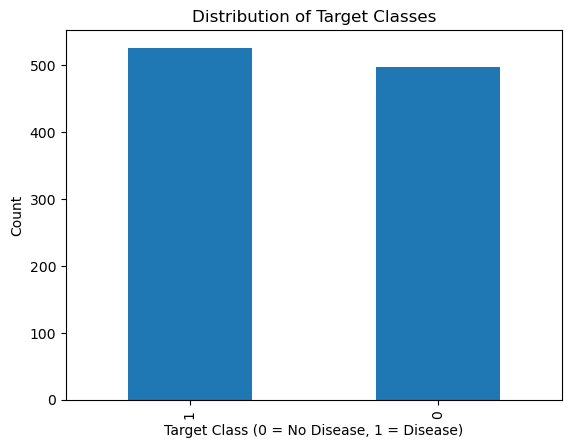

In [31]:
import matplotlib.pyplot as plt

target_counts = df["thalassemia"].value_counts()
plt.figure()
target_counts.plot(kind="bar")
plt.title("Distribution of Target Classes")
plt.xlabel("Target Class (0 = No Disease, 1 = Disease)")
plt.ylabel("Count")
plt.show()


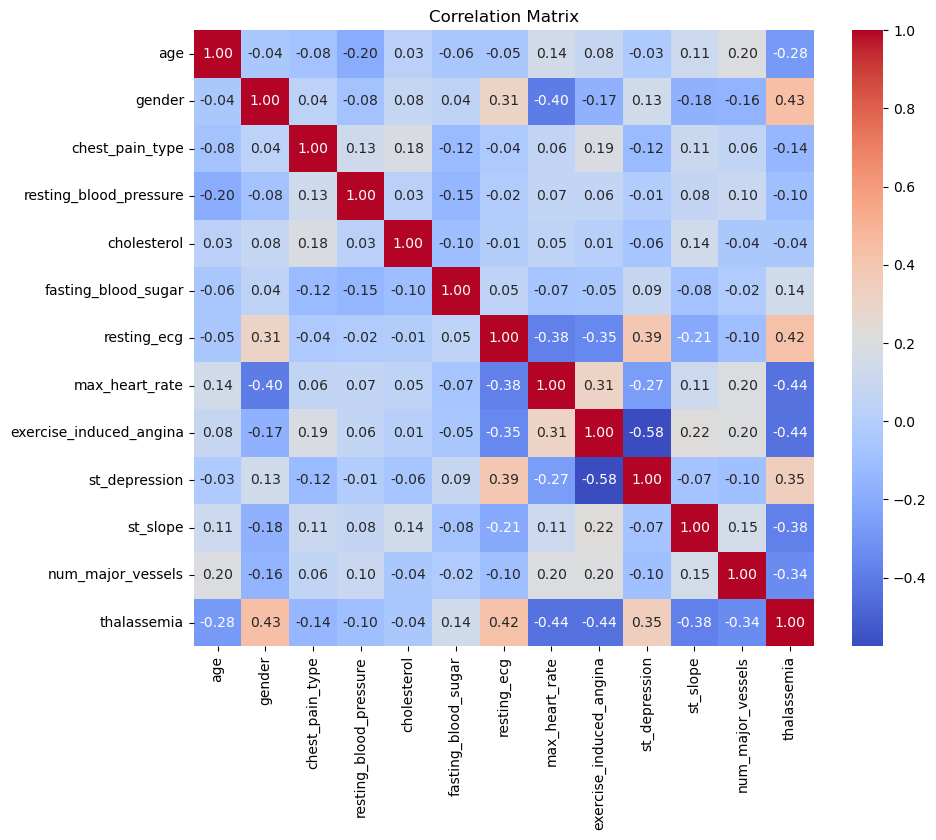

In [32]:

import numpy as np
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

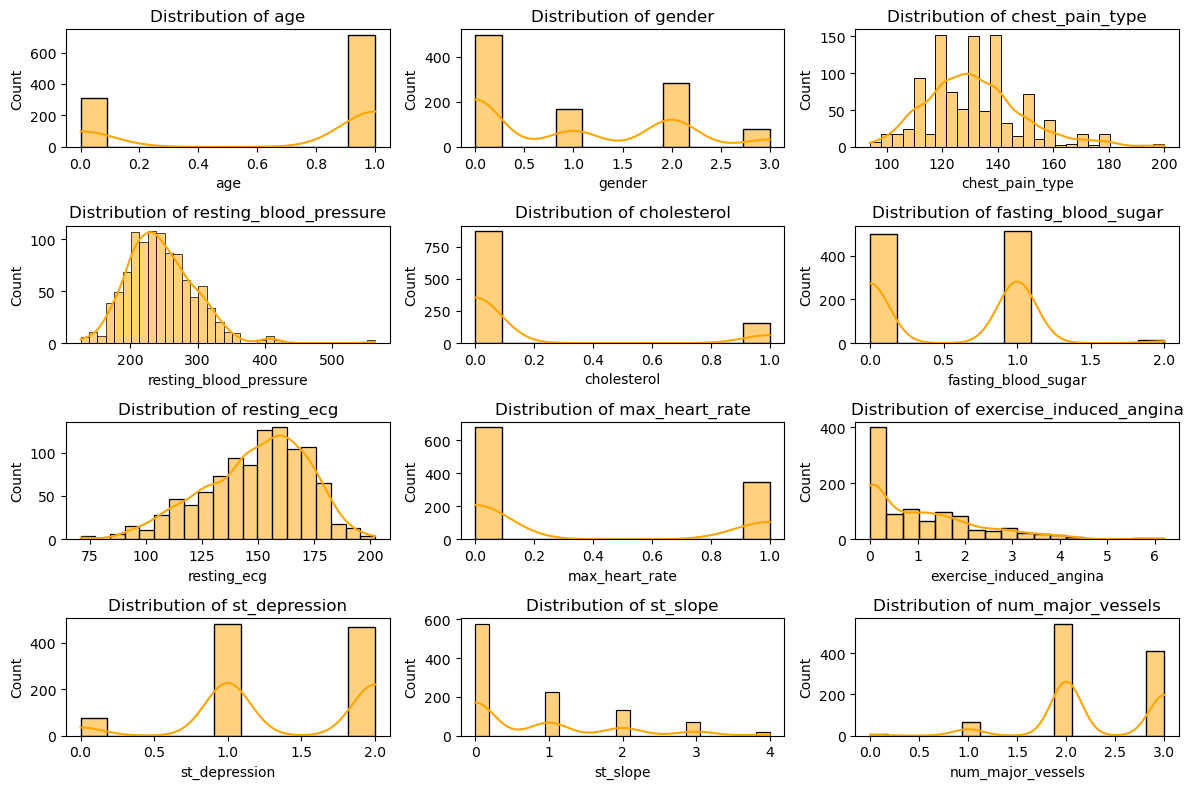

In [33]:
import seaborn as sns
plt.figure(figsize=(12, 8))
for i, col in enumerate(["age",
    "gender",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels"],1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], kde=True, color="orange")
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [34]:
df.fillna(df.median(numeric_only=True), inplace=True)


In [36]:

cols_to_scale = [
    "age",
    "gender",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels"
]

for col in cols_to_scale:
    df[col] = df[col] / df[col].max()


print(df[cols_to_scale].head())


    age  gender  chest_pain_type  resting_blood_pressure  cholesterol  \
53  1.0     0.0            0.700                0.359929          1.0   
70  1.0     0.0            0.725                0.308511          0.0   
61  1.0     0.0            0.740                0.359929          0.0   
62  0.0     0.0            0.690                0.521277          1.0   
58  0.0     0.0            0.500                0.439716          0.0   

    fasting_blood_sugar  resting_ecg  max_heart_rate  exercise_induced_angina  \
53                  0.0     0.767327             1.0                 0.500000   
70                  0.5     0.618812             1.0                 0.419355   
61                  0.5     0.797030             0.0                 0.000000   
62                  0.5     0.524752             0.0                 0.306452   
58                  0.0     0.603960             0.0                 0.161290   

    st_depression  st_slope  num_major_vessels  
53            0.0      0.

In [42]:
feature_cols=[    "age",
    "gender",
    "chest_pain_type",
    "resting_blood_pressure",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "num_major_vessels"]
X=df[feature_cols]
y=df['thalassemia']

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=25,random_state=0)
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(max_iter=1000)
logreg.fit(X_train,y_train)
y_pred=logreg.predict(X_test)
from sklearn import metrics 
cnf_matrix=metrics.confusion_matrix(y_test,y_pred)
cnf_matrix


array([[10,  3],
       [ 1, 11]])

In [45]:

print("accuracy:",metrics.accuracy_score(y_test,y_pred))
print("precision:",metrics.precision_score(y_test,y_pred))
print("recall:",metrics.recall_score(y_test,y_pred))
print("f1",metrics.f1_score(y_test,y_pred))
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)

accuracy: 0.84
precision: 0.7857142857142857
recall: 0.9166666666666666
f1 0.8461538461538461
ROC AUC Score: 0.8429487179487177
